# Phase 5: DPO Alignment From Scratch

Phases 1-4 built and understood architectures. This phase covers
alignment: taking a trained language model (our Phase 4 GPT) and
shifting its behavior using preference data, with Direct Preference
Optimization implemented from scratch.

## What this notebook demonstrates
1. A synthetic preference dataset built with an automatic anti-repetition signal
2. The DPO loss, derived from the KL-regularized RLHF objective and checked with sanity tests
3. Training dynamics: loss, implicit reward margin, win rate, and drift from the reference
4. Before/after generation, including the visible "alignment tax"
5. A beta ablation showing beta controls KL drift, with a noisy downstream metric

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

## 1. The Preference Signal

For each prompt we sampled 4 completions from the base GPT (temperature 1.2),
scored each by n-gram repetition rate, and labeled the least repetitive as the
winner and the most repetitive as the loser. Pairs with a repetition gap
below 0.05 were discarded.

In [2]:
print("Example pair (Pair 3 from scripts/test_preference_data.py)")
print("Prompt: 'ghter to him, and wi'")
print("WINNER (repetition=0.000): 'th word if Bacaun to\\nhaot, and magelt to'")
print("LOSER  (repetition=0.108): 'th to to to Mades in toful.\\nPletchry giv'")
print("\n100 pairs: avg winner repetition = 0.0000, avg loser repetition = 0.0646")

Example pair (Pair 3 from scripts/test_preference_data.py)
Prompt: 'ghter to him, and wi'
WINNER (repetition=0.000): 'th word if Bacaun to\nhaot, and magelt to'
LOSER  (repetition=0.108): 'th to to to Mades in toful.\nPletchry giv'

100 pairs: avg winner repetition = 0.0000, avg loser repetition = 0.0646


## 2. The DPO Loss and Its Sanity Checks

    L_DPO = -log sigmoid( beta * [ log(pi/pi_ref)(y_w) - log(pi/pi_ref)(y_l) ] )

Checks run before any training (scripts/test_dpo_loss.py):
- Real Shakespeare continuation: log-prob -63.86. Random nonsense: -217.87.
- With policy == reference, real winner vs nonsense loser: loss 0.5309, margin +0.356.
- Total gradient norm through the whole loss: 31.87, finite and non-zero.

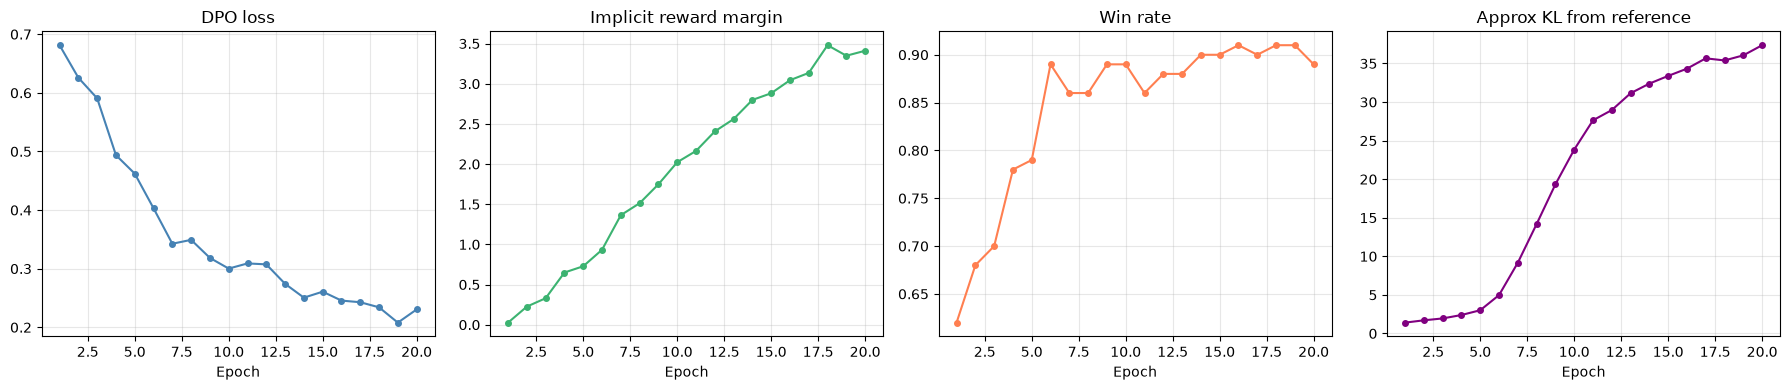

Loss, margin and win rate all improve as expected.
Approx KL rises ~27x (1.40 -> 37.37) and has not plateaued by epoch 20.


In [3]:
loss   = [0.6813,0.6258,0.5907,0.4937,0.4622,0.4031,0.3426,0.3492,0.3184,0.3002,
          0.3090,0.3074,0.2742,0.2506,0.2608,0.2456,0.2428,0.2341,0.2080,0.2305]
margin = [0.0263,0.2258,0.3302,0.6500,0.7282,0.9332,1.3640,1.5130,1.7484,2.0229,
          2.1635,2.4065,2.5601,2.7983,2.8816,3.0441,3.1350,3.4797,3.3487,3.4106]
win    = [0.62,0.68,0.70,0.78,0.79,0.89,0.86,0.86,0.89,0.89,
          0.86,0.88,0.88,0.90,0.90,0.91,0.90,0.91,0.91,0.89]
kl     = [1.4044,1.7044,1.9478,2.3923,3.0118,4.9743,9.1730,14.1871,19.3352,23.8356,
          27.6355,28.9604,31.1451,32.3918,33.3905,34.3282,35.6690,35.3934,36.0571,37.3700]
epochs = range(1, 21)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, series, color) in zip(axes, [
    ("DPO loss", loss, "steelblue"),
    ("Implicit reward margin", margin, "mediumseagreen"),
    ("Win rate", win, "coral"),
    ("Approx KL from reference", kl, "purple"),
]):
    ax.plot(epochs, series, marker='o', markersize=4, color=color)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/phase5_dpo_training.png", dpi=150)
plt.show()

print("Loss, margin and win rate all improve as expected.")
print("Approx KL rises ~27x (1.40 -> 37.37) and has not plateaued by epoch 20.")

## 3. Before vs After: Alignment Tax

Free-running generation from the prompt "ROMEO:" (single sample each,
temperature 0.8).

In [4]:
print("BASE MODEL (repetition rate 0.0837):")
print("""ROMEO:
But deeps the cervien.
That the your him day, strass 't and in have dome shall to me tand bout to akin swe ande mput thowe;
He are are.""")

print("\nDPO-ALIGNED, beta=0.1 (repetition rate 0.0345):")
print("""ROMEO:
Why deementery?

News LecOMINO:
Go ROLUCHNRY CLAM:
Gexeencesst I VINIUS:
Fecolmen beces mestereshecomeck.""")

print("\nThe repetition metric dropped, but the aligned text is visibly more")
print("chaotic (mid-word capitalization). Caveat: each figure is a single")
print("sampled generation, so the comparison is suggestive, not statistically firm.")

BASE MODEL (repetition rate 0.0837):
ROMEO:
But deeps the cervien.
That the your him day, strass 't and in have dome shall to me tand bout to akin swe ande mput thowe;
He are are.

DPO-ALIGNED, beta=0.1 (repetition rate 0.0345):
ROMEO:
Why deementery?

News LecOMINO:
Go ROLUCHNRY CLAM:
Gexeencesst I VINIUS:
Fecolmen beces mestereshecomeck.

The repetition metric dropped, but the aligned text is visibly more
chaotic (mid-word capitalization). Caveat: each figure is a single
sampled generation, so the comparison is suggestive, not statistically firm.


## 4. Beta Ablation

Same preference pairs, same starting checkpoint, same learning rate;
only beta varies.

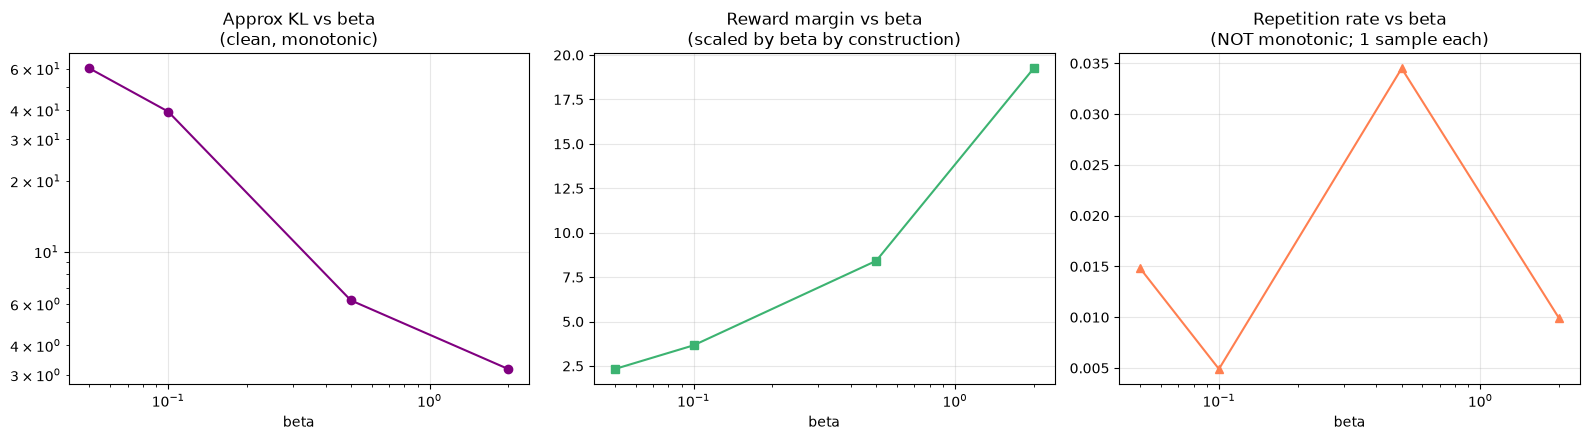

Beta        Margin        KL    Win Rate    Repetition
0.05        2.3291   60.1029        0.90        0.0148
0.1         3.6618   39.3926        0.95        0.0049
0.5         8.4204    6.2096        0.98        0.0345
2.0        19.2505    3.1712        0.97        0.0099


In [5]:
betas       = [0.05, 0.1, 0.5, 2.0]
final_kl    = [60.1029, 39.3926, 6.2096, 3.1712]
final_margin= [2.3291, 3.6618, 8.4204, 19.2505]
win_rate    = [0.90, 0.95, 0.98, 0.97]
repetition  = [0.0148, 0.0049, 0.0345, 0.0099]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(betas, final_kl, marker='o', color="purple")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Approx KL vs beta\n(clean, monotonic)")

axes[1].plot(betas, final_margin, marker='s', color="mediumseagreen")
axes[1].set_xscale("log")
axes[1].set_title("Reward margin vs beta\n(scaled by beta by construction)")

axes[2].plot(betas, repetition, marker='^', color="coral")
axes[2].set_xscale("log")
axes[2].set_title("Repetition rate vs beta\n(NOT monotonic; 1 sample each)")

for ax in axes:
    ax.set_xlabel("beta")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/phase5_beta_ablation.png", dpi=150)
plt.show()

print(f"{'Beta':<8}{'Margin':>10}{'KL':>10}{'Win Rate':>12}{'Repetition':>14}")
for b, m, k, w, r in zip(betas, final_margin, final_kl, win_rate, repetition):
    print(f"{b:<8}{m:>10.4f}{k:>10.4f}{w:>12.2f}{r:>14.4f}")

## Key Findings - Phase 5

1. **DPO implemented from scratch works mechanically**: loss fell 0.68 -> 0.23,
   reward margin rose 0.03 -> 3.41, win rate 62% -> 89% on the training pairs.

2. **Beta controls drift from the reference, as theory predicts**: approximate
   KL fell monotonically from 60.1 (beta=0.05) to 3.2 (beta=2.0), about a 19x range.

3. **Reward margin is not a quality metric across betas**: the DPO logit is
   beta times a log-ratio difference, so margin scales with beta by construction.

4. **The downstream behavior metric was noisy and non-monotonic**: repetition
   was best at beta=0.1 (0.0049) and worse at beta=0.5 (0.0345) than at
   beta=0.05. Each value comes from one sampled generation, so no ordering
   claim is justified.

5. **Alignment tax is visible**: aligned generations were more chaotic than
   the base model at every beta tested. With ~104K parameters, 100 pairs and
   a fixed learning rate, we did not find a setting that reduced repetition
   while keeping fluency.

6. **Limitations**: the KL figure is a proxy (mean absolute log-prob change on
   winner completions), not an exact KL, and repetition needs to be averaged
   over many samples per beta. That is the natural next experiment.

## Capstone complete
    Phase 1: backprop, optimizers, regularization      (NumPy)
    Phase 2: convolution, depth, residual connections  (CNNs)
    Phase 3: gradients through time, LSTM gates        (RNNs)
    Phase 4: attention, transformers, GPT              (Transformers)
    Phase 5: preference optimization                   (Alignment)